In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Sequence likelihood: one shift, two different masks

Day 17 · Chapter 11. CPU, authored synthetic data, no downloads. Predict before each reference, change one declared variable, and interpret the result. Code is complete so the notebook runs from beginning to end. Completing its execution is material verification, not an assessment of learner mastery.

[Canonical chapter](../../book/chapters/11-direct-preference-optimization.md)


In [2]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / "src" / "dongxi_llms").is_dir():
    if root.parent == root:
        raise RuntimeError("Open this notebook within the Dongxi_LLMs repository")
    root = root.parent
sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
blue, orange, green = "#356a9b", "#b97139", "#3d8268"



## Exercise 1: align the target boundary

For `[prompt, prompt, A, EOS, PAD]`, which state predicts A? Predict the response-target mask after shifting once. The heatmap labels token positions, not linguistic characters.


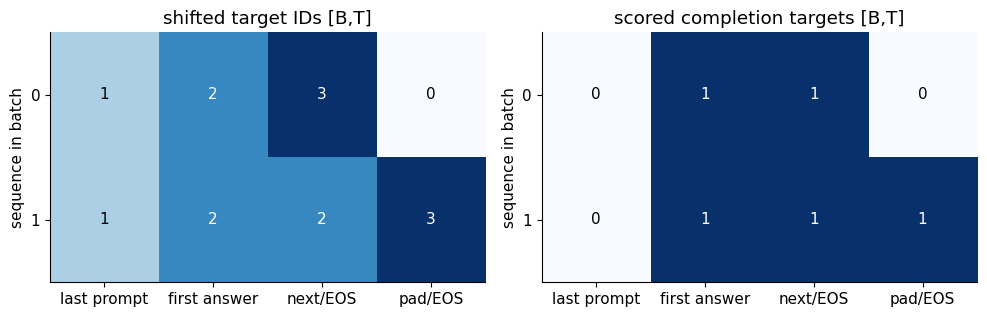

{'sequence_logps': [-2.772588722239781, -4.1588830833596715], 'per_token_average': [-1.3862943611198906, -1.3862943611198906]}


In [3]:
from dongxi_llms.dpo_lab import sequence_logps,dpo_loss
ids=torch.tensor([[0,1,2,3,0],[0,1,2,2,3]])
attention=torch.tensor([[1,1,1,1,0],[1,1,1,1,1]],dtype=torch.bool)
completion=torch.tensor([[0,0,1,1,0],[0,0,1,1,1]],dtype=torch.bool)
labels=ids[:,1:]
mask=completion[:,1:]&attention[:,1:]
logits=torch.zeros(2,4,4,dtype=torch.float64,requires_grad=True)
sums=sequence_logps(logits,labels,mask)
averages=sequence_logps(logits,labels,mask,average=True)
fig,axes=plt.subplots(1,2,figsize=(10,3.3))
for ax,array,title in zip(axes,[labels,mask],["shifted target IDs [B,T]","scored completion targets [B,T]"]):
    ax.imshow(array.numpy(),vmin=0,vmax=3 if title.startswith("shifted") else 1,cmap="Blues",aspect="auto")
    for b in range(2):
        for t in range(4):ax.text(t,b,str(int(array[b,t])),ha="center",va="center",color="white" if int(array[b,t]) > (1 if title.startswith("shifted") else 0) else "black")
    ax.set(xticks=range(4),xticklabels=["last prompt","first answer","next/EOS","pad/EOS"],
           yticks=range(2),ylabel="sequence in batch",title=title)
plt.tight_layout();plt.show()
print({"sequence_logps":sums.detach().tolist(),"per_token_average":averages.detach().tolist()})


![Saved reference plot for 02 sequence likelihood and masks, figure 1](../figures/chapter-11/day-17-02_sequence_likelihood_and_masks-01.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Solution:** A is predicted from the final prompt state. EOS is a scored target if included in the response convention. The prompt remains context even though its labels do not enter the response sum. Padding attention and completion loss masks serve different purposes.

## Exercise 2: inspect masked gradients

Will unscored predictive logits receive a direct likelihood gradient? Will this imply prompt embeddings cannot receive gradients in a transformer?


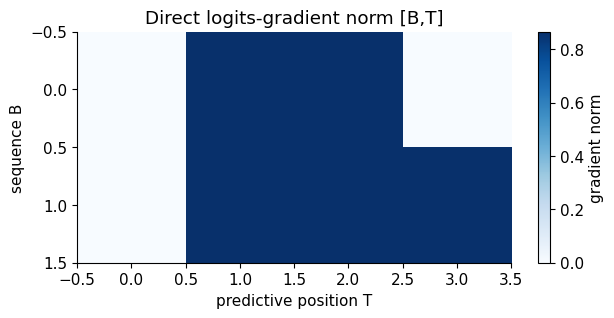

A real transformer can still send answer-loss gradients through prompt context paths.


In [4]:
sums.sum().backward()
torch.testing.assert_close(logits.grad[~mask],torch.zeros_like(logits.grad[~mask]))
fig,ax=plt.subplots(figsize=(7,3))
norm=logits.grad.norm(dim=-1)
image=ax.imshow(norm.numpy(),aspect="auto",cmap="Blues")
ax.set(xlabel="predictive position T",ylabel="sequence B",title="Direct logits-gradient norm [B,T]")
fig.colorbar(image,ax=ax,label="gradient norm");plt.show()
print("A real transformer can still send answer-loss gradients through prompt context paths.")


![Saved reference plot for 02 sequence likelihood and masks, figure 2](../figures/chapter-11/day-17-02_sequence_likelihood_and_masks-02.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Solution:** these independent leaf logits have zero direct gradient outside the score mask. In a transformer, answer states attend to prompt representations, so the prompt embeddings can receive indirect gradients. This leaf-logit exercise does not contradict that path.

## Exercise 3: sum versus average

At equal token probabilities, why do the two sequences have different sums and equal averages? Would replacing sums with averages preserve ordinary DPO's sequence-distribution derivation?


In [5]:
expected=-mask.sum(1)*torch.log(torch.tensor(4.,dtype=torch.float64))
torch.testing.assert_close(sums.detach(),expected)
torch.testing.assert_close(averages.detach(),torch.full((2,),-float(torch.log(torch.tensor(4.))),dtype=torch.float64),
                           atol=1e-7,rtol=1e-7)
c=torch.tensor([-2.],requires_grad=True);r=torch.tensor([-3.],requires_grad=True)
rc=c.detach().clone().requires_grad_();rr=r.detach().clone().requires_grad_()
loss,margin=dpo_loss(c,r,rc,rr,beta=.2);loss.backward()
print({"initial_margin":float(margin.detach()),"chosen_gradient":float(c.grad),
       "rejected_gradient":float(r.grad),"reference_grad":rc.grad})


{'initial_margin': 0.0, 'chosen_gradient': -0.10000000149011612, 'rejected_gradient': 0.10000000149011612, 'reference_grad': None}


**Solution:** summing counts every response-token likelihood factor. Averaging defines a different quantity. A fixed reference has no gradient, and identical policy/reference branch scores produce zero initial relative margin. Every real branch must share tokenizer, template, EOS convention, and mask definition; tests of these tensors alone cannot validate an unseen HF template.
